# Crosscorrelation- Turning angle and error angle (250 fps) 


Processing: Trial2_180rpmxyzpts
  Length after alignment: 67
  → Peak lag: -0.1680 sec | Peak corr: 45.055


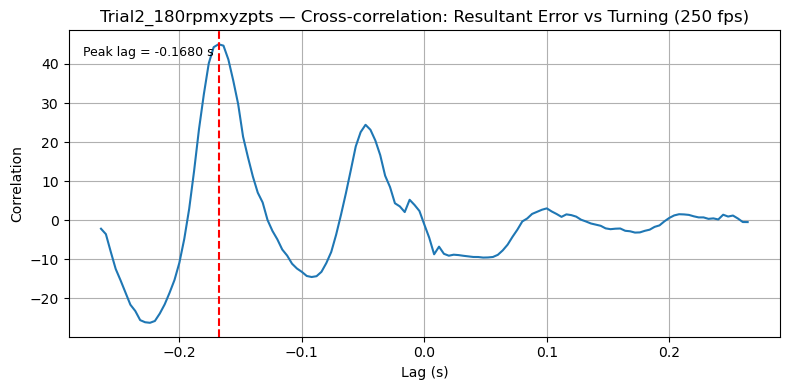


Processing: Trial2_200rpmxyzpts
  Length after alignment: 14
  → Peak lag: 0.0480 sec | Peak corr: 3.682


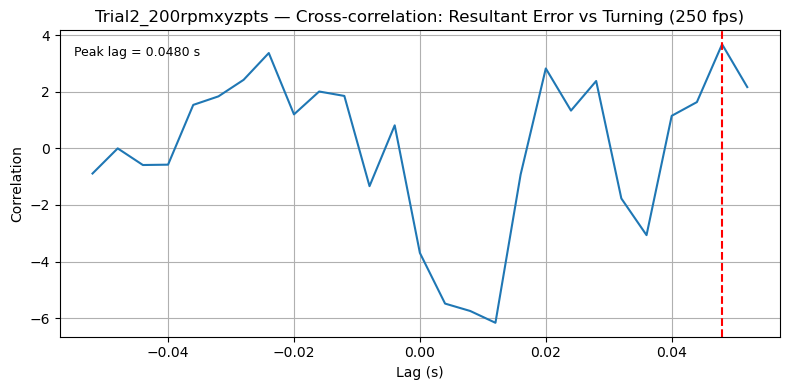


Processing: Trial3_180rpmxyzpts
  Length after alignment: 14
  → Peak lag: -0.0240 sec | Peak corr: 3.092


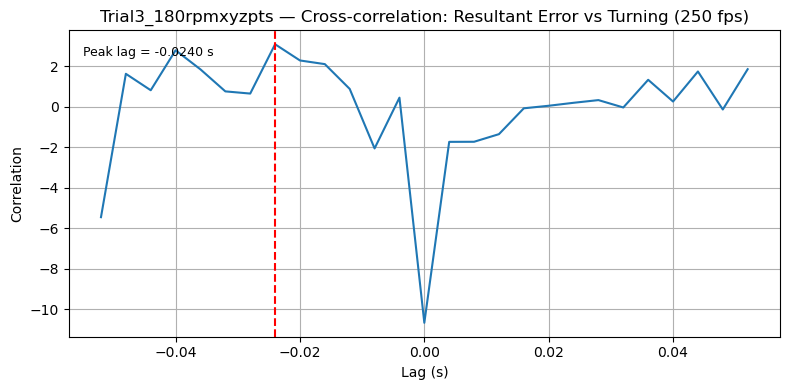


Processing: Trial4_400rpmxyzpts
  Length after alignment: 35
  → Peak lag: -0.0240 sec | Peak corr: 14.869


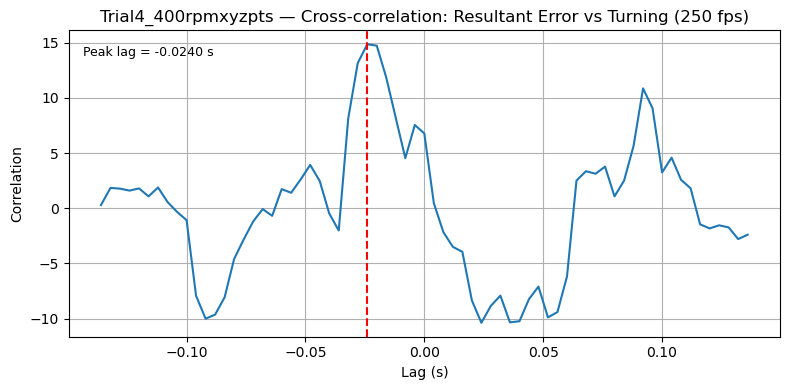


Processing: Trial5_180rpmxyzpts
  Length after alignment: 42
  → Peak lag: 0.0000 sec | Peak corr: 25.451


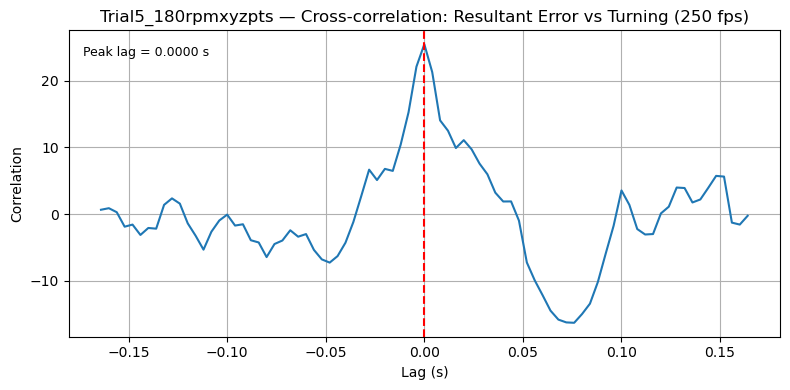


Processing: Trial5_400rpmxyzpts
  Length after alignment: 57
  → Peak lag: 0.0160 sec | Peak corr: 23.015


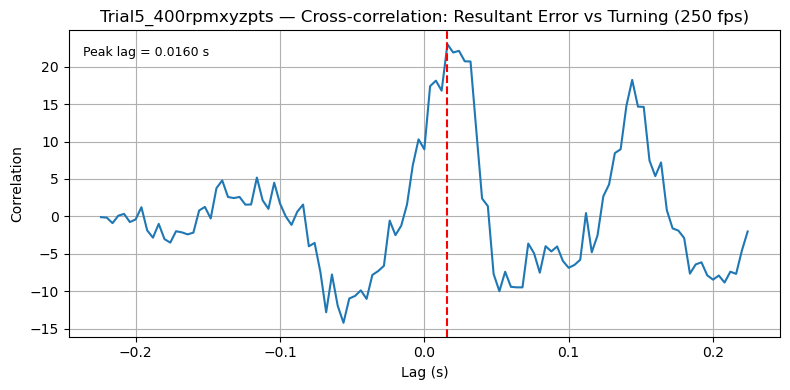


Processing: Trial7_400rpmxyzpts
  Length after alignment: 58
  → Peak lag: -0.0600 sec | Peak corr: 24.076


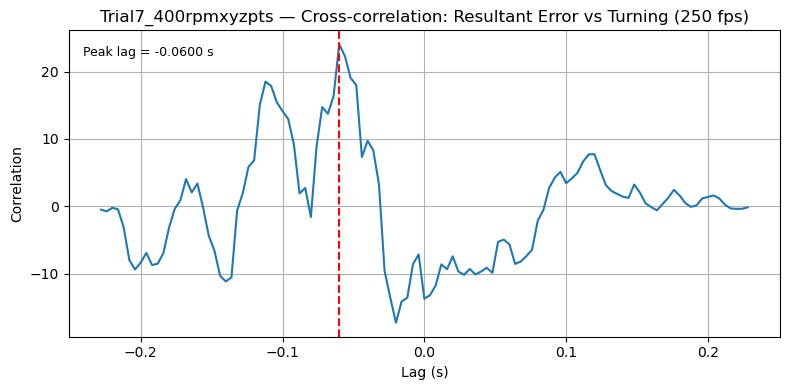

In [1]:
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

ERR_DIR  = r"./../../dataFolders/MuscaChasingBeads/ErrorAngle_DistFromBead/ErrorAngle_DistFromBead_Subsampled"
TURN_DIR = r"./../../dataFolders/MuscaChasingBeads/turning_angle/subsample_turning_angle_center-based"
OUT_DIR  = r"./../../dataFolders/MuscaChasingBeads/Figures/CrossCorr/250fps"
FPS = 250

def compute_cross_correlation(x, y):
    x = x - np.mean(x)
    y = y - np.mean(y)
    x = x / (np.std(x) + 1e-8)
    y = y / (np.std(y) + 1e-8)
    corr = np.correlate(x, y, mode='full')
    lags = np.arange(-len(x)+1, len(x))
    return corr, lags

os.makedirs(OUT_DIR, exist_ok=True)

err_files = glob.glob(os.path.join(ERR_DIR, "*_CHASE_METRICS.csv"))

for err_path in err_files:
    fname = os.path.basename(err_path)
    trial = fname.replace("_CHASE_METRICS.csv", "")
    print(f"\nProcessing: {trial}")

    turn_path = os.path.join(TURN_DIR, f"{trial}_TURNING_ANGLE_TRIMMED.csv")
    if not os.path.exists(turn_path):
        print(" No trimmed turning file")
        continue

    df_err  = pd.read_csv(err_path)
    df_turn = pd.read_csv(turn_path)

    df_merged = pd.merge(df_err, df_turn, on="frame", how="inner")
    print(f"  Length after alignment: {len(df_merged)}")

    error = df_merged["error_angle_head_deg"].values
    turn  = df_merged["turning_angle_3d_deg"].values

    valid = np.isfinite(error) & np.isfinite(turn)
    error = error[valid]
    turn  = turn[valid]

    if len(error) < 3:
        print(" Too few points after cleaning")
        continue

    corr, lags = compute_cross_correlation(error, turn)
    lag_time = lags / FPS

    peak_idx = np.argmax(corr)
    peak_lag = lag_time[peak_idx]
    peak_corr = corr[peak_idx]
    print(f"  → Peak lag: {peak_lag:.4f} sec | Peak corr: {peak_corr:.3f}")

    plt.figure(figsize=(8,4))
    plt.plot(lag_time, corr)
    plt.axvline(peak_lag, linestyle="--", color="red")
    plt.text(0.02, 0.95, f"Peak lag = {peak_lag:.4f} s",
             transform=plt.gca().transAxes, fontsize=9,
             verticalalignment='top')
    plt.title(f"{trial} — Cross-correlation: Resultant Error vs Turning (250 fps)")
    plt.xlabel("Lag (s)")
    plt.ylabel("Correlation")
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(os.path.join(OUT_DIR, f"{trial}_crosscorr_250fps_trimmed_aligned.png"), dpi=150, bbox_inches='tight')
    plt.show()

# Crosscorrelation- Turning angle and error angle (1000 fps) 


Processing: Trial2_180rpmxyzpts
  After merge:       273
  After NaN removal: 273
  → Peak lag: -0.1780 sec | Peak corr: 113.582


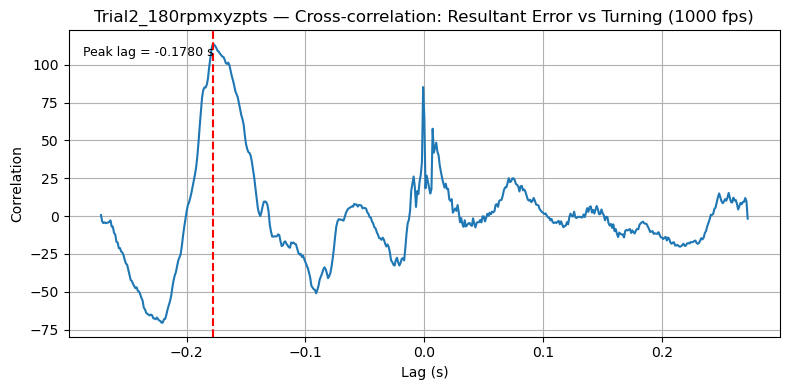


Processing: Trial2_200rpmxyzpts
  After merge:       62
  After NaN removal: 62
  → Peak lag: -0.0270 sec | Peak corr: 28.899


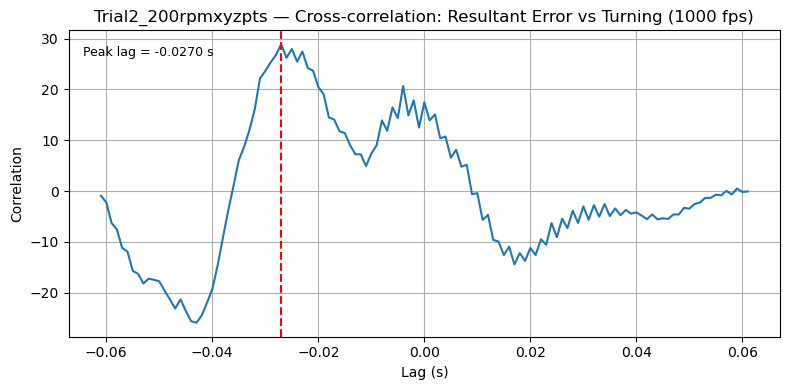


Processing: Trial3_180rpmxyzpts
  After merge:       60
  After NaN removal: 60
  → Peak lag: -0.0010 sec | Peak corr: 13.542


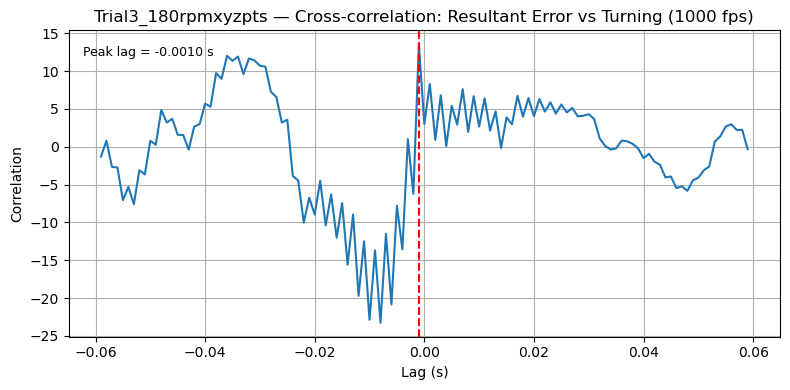


Processing: Trial4_400rpmxyzpts
  After merge:       146
  After NaN removal: 146
  → Peak lag: -0.0430 sec | Peak corr: 92.688


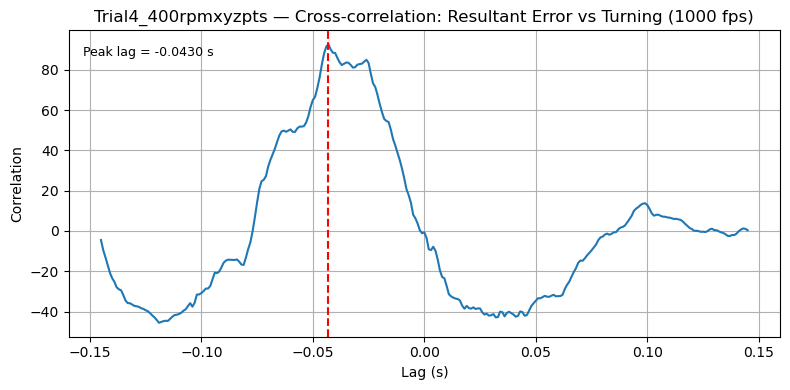


Processing: Trial5_180rpmxyzpts
  After merge:       174
  After NaN removal: 174
  → Peak lag: 0.1430 sec | Peak corr: 49.915


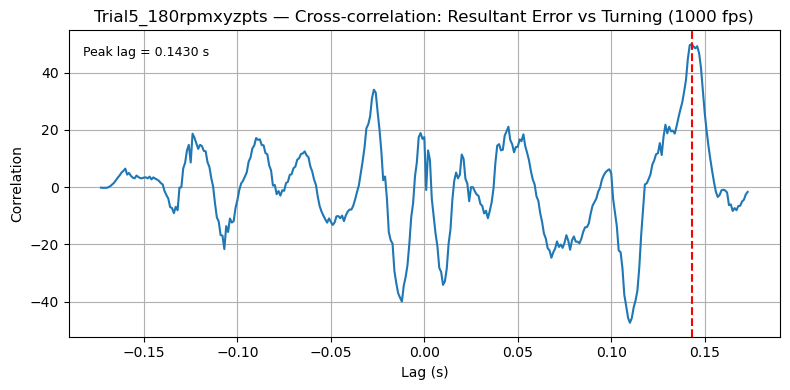


Processing: Trial5_400rpmxyzpts
  After merge:       234
  After NaN removal: 234
  → Peak lag: 0.0000 sec | Peak corr: 144.370


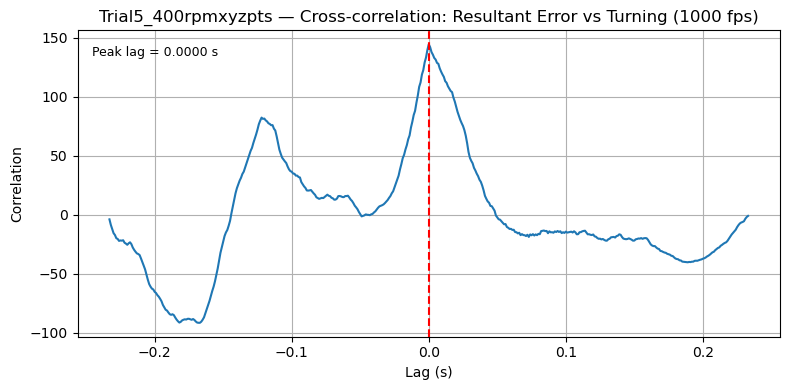


Processing: Trial7_400rpmxyzpts
  After merge:       238
  After NaN removal: 238
  → Peak lag: -0.1140 sec | Peak corr: 130.672


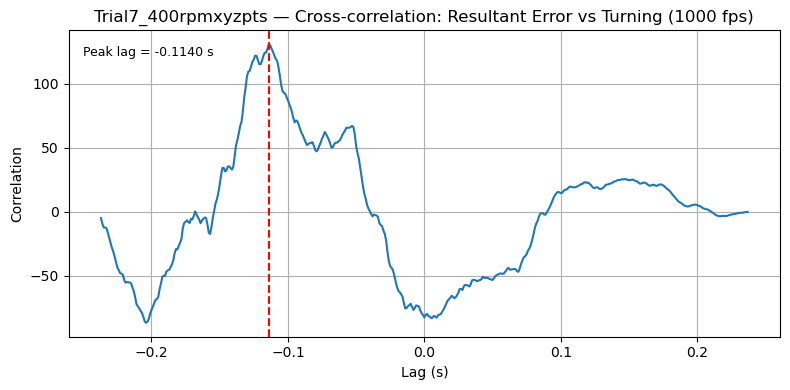

In [2]:
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

ERR_DIR  = r"./../../dataFolders/MuscaChasingBeads/ErrorAngle_DistFromBead/ErrorAngle_DistFromBead_Subsampled_1000fps"
TURN_DIR = r"./../../dataFolders/MuscaChasingBeads/turning_angle/subsample_turning_angle_center-based_1000fps"
OUT_DIR  = r"./../../dataFolders/MuscaChasingBeads/Figures/CrossCorr/1000fps"
FPS = 1000

def compute_cross_correlation(x, y):
    x = x - np.mean(x)
    y = y - np.mean(y)
    x = x / (np.std(x) + 1e-8)
    y = y / (np.std(y) + 1e-8)
    corr = np.correlate(x, y, mode='full')
    lags = np.arange(-len(x)+1, len(x))
    return corr, lags

os.makedirs(OUT_DIR, exist_ok=True)

err_files = glob.glob(os.path.join(ERR_DIR, "*_CHASE_METRICS_1000fps.csv"))

for err_path in err_files:
    fname = os.path.basename(err_path)
    trial = fname.replace("_CHASE_METRICS_1000fps.csv", "")
    print(f"\nProcessing: {trial}")

    turn_path = os.path.join(TURN_DIR, f"{trial}_TURNING_ANGLE_1000fps_TRIMMED.csv")
    if not os.path.exists(turn_path):
        print("  No trimmed turning file")
        continue

    df_err  = pd.read_csv(err_path)
    df_turn = pd.read_csv(turn_path)

    df_merged = pd.merge(df_err, df_turn, on="frame", how="inner")
    print(f"  After merge:       {len(df_merged)}")

    error = df_merged["error_angle_head_deg"].values
    turn  = df_merged["turning_angle_3d_deg"].values

    valid = np.isfinite(error) & np.isfinite(turn)
    error = error[valid]
    turn  = turn[valid]
    print(f"  After NaN removal: {len(error)}")

    if len(error) < 3:
        print("  Too few points after cleaning")
        continue

    corr, lags = compute_cross_correlation(error, turn)
    lag_time = lags / FPS

    peak_idx = np.argmax(corr)
    peak_lag = lag_time[peak_idx]
    peak_corr = corr[peak_idx]
    print(f"  → Peak lag: {peak_lag:.4f} sec | Peak corr: {peak_corr:.3f}")

    plt.figure(figsize=(8,4))
    plt.plot(lag_time, corr)
    plt.axvline(peak_lag, linestyle="--", color="red")
    plt.text(0.02, 0.95, f"Peak lag = {peak_lag:.4f} s",
             transform=plt.gca().transAxes, fontsize=9,
             verticalalignment='top')
    plt.title(f"{trial} — Cross-correlation: Resultant Error vs Turning (1000 fps)")
    plt.xlabel("Lag (s)")
    plt.ylabel("Correlation")
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(os.path.join(OUT_DIR, f"{trial}_crosscorr_1000fps.png"), dpi=150, bbox_inches='tight')
    plt.show()

# Crosscorrelation- Turning angle and error angle (2500 fps) (cross corr and box plot)

In [3]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── PATHS ─────────────────────────────────────────────────────
BASE_DIR = os.path.abspath(
    os.path.join(os.path.dirname(__file__), "..", "..", "dataFolders", "MuscaChasingBeads")
) if "__file__" in globals() else os.path.abspath("./../../dataFolders/MuscaChasingBeads")

TURN_DIR = os.path.join(
    BASE_DIR,
    "Turning_angle", "Trimmed_2500fps", "Trimmed_2500fps_Smoothed"
)

ERROR_DIR = os.path.join(BASE_DIR, "ErrorAngle_DistFromBead")

# ── OUTPUT PATHS ──────────────────────────────────────────────
RAW_DIR = os.path.join(BASE_DIR, "Figures", "Analysis", "Turning_vs_Error_Angle")
OUT_DIR = os.path.join(BASE_DIR, "Figures", "Analysis", "Turning_vs_Error_Angle_Crosscorr")
OUT_BOX = os.path.join(BASE_DIR, "Figures", "Analysis", "Turning_vs_Error_Angle_BoxPlots")

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(OUT_BOX, exist_ok=True)

FPS = 2500
MAX_LAG_S = 0.2

results = []

# ── HELPERS ───────────────────────────────────────────────────
def get_col(df, base):
    for name in [f"{base}_smooth", base]:
        if name in df.columns:
            return df[name].values
    raise KeyError(f"{base} not found")

def normalize(x):
    std = np.std(x)
    return (x - np.mean(x)) / std if std != 0 else x - np.mean(x)

def cross_corr_norm(x, y):
    x = normalize(x)
    y = normalize(y)

    N = len(x)
    corr = np.correlate(x, y, mode='full') / N
    lags = np.arange(-N+1, N)
    lag_t = lags / FPS

    mask = np.abs(lag_t) <= MAX_LAG_S
    return corr[mask], lags[mask], lag_t[mask]

def get_peak(corr, lags):
    idx = np.argmax(corr)
    return lags[idx]

def align_signals(x, y, lag):
    if lag > 0:
        return x[:-lag], y[lag:]
    elif lag < 0:
        return x[-lag:], y[:lag]
    return x, y

def regression_stats(x, y):
    if len(x) < 2:
        return np.nan, np.nan, np.nan
    m, c = np.polyfit(x, y, 1)
    y_pred = m*x + c
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan
    return r2, m, c

# ── PANEL PLOTS ───────────────────────────────────────────────
def plot_horizontal_panels(err_h, turn_h, trial):
    t = np.arange(len(err_h)) / FPS

    fig, axes = plt.subplots(2, 1, figsize=(7,6), sharex=True)

    axes[0].plot(t, err_h)
    axes[0].set_ylabel("Error (deg)")
    axes[0].set_title("Horizontal Error")
    axes[0].grid(True)

    axes[1].plot(t, turn_h)
    axes[1].set_ylabel("Turning (deg)")
    axes[1].set_title("Horizontal Turning")
    axes[1].set_xlabel("Time (s)")
    axes[1].grid(True)

    plt.suptitle(trial)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(os.path.join(RAW_DIR, f"{trial}_horizontal.png"),
                dpi=300, bbox_inches="tight")
    plt.close()


def plot_vertical_panels(err_v, turn_v, trial):
    t = np.arange(len(err_v)) / FPS

    fig, axes = plt.subplots(2, 1, figsize=(7,6), sharex=True)

    axes[0].plot(t, err_v)
    axes[0].set_ylabel("Error (deg)")
    axes[0].set_title("Vertical Error")
    axes[0].grid(True)

    axes[1].plot(t, turn_v)
    axes[1].set_ylabel("Turning (deg)")
    axes[1].set_title("Vertical Turning")
    axes[1].set_xlabel("Time (s)")
    axes[1].grid(True)

    plt.suptitle(trial)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(os.path.join(RAW_DIR, f"{trial}_vertical.png"),
                dpi=300, bbox_inches="tight")
    plt.close()

# ── ANALYSIS ──────────────────────────────────────────────────
def analyze_trial(err, turn, axis, trial):

    corr, lags, lag_t = cross_corr_norm(err, turn)
    lag = get_peak(corr, lags)
    lag_sec = lag / FPS

    x_aligned, y_aligned = align_signals(err, turn, lag)

    if len(x_aligned) < 50:
        return

    r2, slope, intercept = regression_stats(x_aligned, y_aligned)

    results.append({
        "trial": trial,
        "axis": axis,
        "lag": lag_sec,
        "r2": r2,
        "slope": slope,
        "intercept": intercept,
        "peak_corr": np.max(corr)
    })

    # ── Cross-correlation ──
    plt.figure(figsize=(5,4))
    plt.plot(lag_t, corr)
    plt.axvline(0, ls="--")
    plt.axvline(lag_sec, ls=":", label=f"Lag = {lag_sec:.3f} s")

    plt.legend(loc="upper right")
    plt.xlabel("Lag (s)")
    plt.ylabel("Correlation")
    plt.title(f"{trial} | {axis}")
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"{trial}_{axis}_xcorr.png"),
                dpi=300, bbox_inches="tight")
    plt.close()

    # ── Scatter ──
    plt.figure(figsize=(5,4))
    plt.scatter(x_aligned, y_aligned, s=10, alpha=0.5)
    
    xfit = np.linspace(min(x_aligned), max(x_aligned), 200)
    yfit = slope * xfit + intercept
    
    plt.plot(xfit, yfit, lw=2)
    
    plt.xlabel("Error (deg)")
    plt.ylabel("Turning (deg)")
    
    # Trial + axis → top-left
    plt.text(
        0.05, 0.95,
        f"{trial} | {axis}",
        transform=plt.gca().transAxes,
        fontsize=10,
        va='top'
    )
    
    # R² + slope → top-right (NO legend anymore)
    plt.text(
        0.95, 0.95,
        f"R² = {r2:.2f}\nslope = {slope:.2f}",
        transform=plt.gca().transAxes,
        fontsize=10,
        ha='right',
        va='top'
    )
    
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"{trial}_{axis}_scatter.png"),
                dpi=300, bbox_inches="tight")
    plt.close()

# ── MAIN LOOP ─────────────────────────────────────────────────
turn_files = glob.glob(os.path.join(TURN_DIR, "*_CENTER_SMOOTHED.csv"))

for path in turn_files:

    fname = os.path.basename(path)
    match = re.search(r"(Trial\d+_\d+rpmxyzpts)", fname)
    if not match:
        continue

    trial = match.group(1)
    err_path = os.path.join(ERROR_DIR, f"{trial}_CHASE_METRICS.csv")

    if not os.path.exists(err_path):
        continue

    turn_df = pd.read_csv(path)
    err_df  = pd.read_csv(err_path)

    turn_h = get_col(turn_df, "turning_angle_xy_deg")
    turn_v = get_col(turn_df, "turning_angle_yz_deg")

    err_h = err_df["error_angle_horiz_deg"].values
    err_v = err_df["error_angle_vert_deg"].values

    n = min(len(turn_h), len(turn_v), len(err_h), len(err_v))
    turn_h, turn_v = turn_h[:n], turn_v[:n]
    err_h, err_v   = err_h[:n], err_v[:n]

    mask = (
        np.isfinite(turn_h) & np.isfinite(turn_v) &
        np.isfinite(err_h) & np.isfinite(err_v)
    )

    turn_h, turn_v = turn_h[mask], turn_v[mask]
    err_h, err_v   = err_h[mask], err_v[mask]

    if len(turn_h) < 50:
        continue

    plot_horizontal_panels(err_h, turn_h, trial)
    plot_vertical_panels(err_v, turn_v, trial)

    analyze_trial(err_h, turn_h, "Horizontal", trial)
    analyze_trial(err_v, turn_v, "Vertical", trial)

# ── RESULTS ───────────────────────────────────────────────────
df = pd.DataFrame(results)

axis_order = ["Horizontal", "Vertical"]
df["axis"] = pd.Categorical(df["axis"], categories=axis_order, ordered=True)

def plot_all_axes(metric, ylabel):

    plt.figure(figsize=(7,5))

    sns.boxplot(
        data=df,
        x="axis",
        y=metric,
        order=axis_order,
        color="#ADD8E6",
        showfliers=False
    )

    sns.stripplot(
        data=df,
        x="axis",
        y=metric,
        order=axis_order,
        color="black",
        jitter=0.25
    )

    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_BOX, f"{metric}.png"),
                dpi=300, bbox_inches="tight")
    plt.close()

plot_all_axes("lag", "Lag (s)")
plot_all_axes("r2", "R²")
plot_all_axes("slope", "Slope")

print("DONE")

DONE


# Speed and distance crosscorrelation 

In [6]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── CONFIG ─────────────────────────────────────────────────────────────
BASE_DIR = r"./../../dataFolders/MuscaChasingBeads"

SPEED_DIR = os.path.join(BASE_DIR, "Speed", "Speed_cleaned")
DIST_DIR  = os.path.join(BASE_DIR, "ErrorAngle_DistFromBead")

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "Figures",
    "Analysis",
    "speed_vs_distance_corr"
)
os.makedirs(OUTPUT_DIR, exist_ok=True)

FPS = 2500

# ── HELPERS ────────────────────────────────────────────────────────────
def normalize(x):
    std = np.std(x)
    return (x - np.mean(x)) / std if std != 0 else x - np.mean(x)

def cross_corr_norm(x, y):
    x = normalize(x)
    y = normalize(y)

    N = len(x)
    corr = np.correlate(x, y, mode='full') / N
    lags = np.arange(-N+1, N)

    return corr, lags


def get_peak_lag(corr, lags):
    # keep only positive peaks (ignore dips)
    mask = corr > 0

    corr_pos = corr[mask]
    lags_pos = lags[mask]

    if len(corr_pos) == 0:
        return 0

    idx = np.argmax(corr_pos)
    return lags_pos[idx]

def align_signals(x, y, lag):
    if lag > 0:
        return x[:-lag], y[lag:]
    elif lag < 0:
        return x[-lag:], y[:lag]
    return x, y

def compute_r2(x, y):
    if len(x) < 2:
        return np.nan
    m, c = np.polyfit(x, y, 1)
    y_pred = m * x + c
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan

# ── STORAGE ────────────────────────────────────────────────────────────
lags_all = []
r2_all   = []

# ── FILES ─────────────────────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(SPEED_DIR, "*_SPEED_CLEAN.csv")))
print("Total files:", len(files))

# ── LOOP ─────────────────────────────────────────────────────────────
for path in files:

    fname = os.path.basename(path)
    match = re.search(r"(Trial\d+_\d+rpmxyzpts)", fname)
    if not match:
        continue

    trial = match.group(1)
    print("Processing:", trial)

    dist_path = os.path.join(DIST_DIR, f"{trial}_CHASE_METRICS.csv")
    if not os.path.exists(dist_path):
        print("Missing distance file:", trial)
        continue

    df_speed = pd.read_csv(path)
    df_dist  = pd.read_csv(dist_path)

    speed = df_speed["speed"].values
    dist  = df_dist["dist_head_m"].values

    # ── ALIGN LENGTH ─────────────────────────
    n = min(len(speed), len(dist))
    speed = speed[:n]
    dist  = dist[:n]

    mask = np.isfinite(speed) & np.isfinite(dist)
    speed = speed[mask]
    dist  = dist[mask]

    if len(speed) < 50:
        continue

    # ── CROSS-CORR ───────────────────────────
    corr, lags = cross_corr_norm(dist, speed)
    lag_t = lags / FPS

    peak_lag = get_peak_lag(corr, lags)
    lag_sec  = peak_lag / FPS

    # ── ALIGN USING LAG ──────────────────────
    dist_aligned, speed_aligned = align_signals(dist, speed, peak_lag)

    if len(dist_aligned) < 50:
        continue

    # ── R² ───────────────────────────────────
    r2 = compute_r2(dist_aligned, speed_aligned)

    lags_all.append(lag_sec)
    r2_all.append(r2)

    # ── CROSS-CORR PLOT ─────────────────────
    plt.figure(figsize=(5,4))
    plt.plot(lag_t, corr)
    plt.axvline(0, ls="--")
    plt.axvline(lag_sec, ls=":", label=f"Lag = {lag_sec:.3f} s")

    plt.xlabel("Lag (s)")
    plt.ylabel("Correlation")
    plt.title("Distance vs Speed")
    plt.suptitle(trial)

    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(OUTPUT_DIR, f"{trial}_xcorr.png"), dpi=300)
    plt.close()

    # ── SCATTER ─────────────────────────────
    plt.figure(figsize=(5,4))
    plt.scatter(dist_aligned, speed_aligned, s=10, alpha=0.5)

    m, c = np.polyfit(dist_aligned, speed_aligned, 1)
    xfit = np.linspace(min(dist_aligned), max(dist_aligned), 200)
    yfit = m * xfit + c

    plt.plot(xfit, yfit, lw=2, label=f"R²={r2:.2f}")

    plt.xlabel("Distance (m)")
    plt.ylabel("Speed")
    plt.title("Distance vs Speed")
    plt.suptitle(trial)

    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(OUTPUT_DIR, f"{trial}_scatter.png"), dpi=300)
    plt.close()

    # ── TIME SERIES ─────────────────────────
    t = np.arange(len(dist)) / FPS

    fig, axes = plt.subplots(2, 1, figsize=(6,5), sharex=True)

    axes[0].plot(t, dist)
    axes[0].set_ylabel("Distance (m)")
    axes[0].set_title("Distance")

    axes[1].plot(t, speed)
    axes[1].set_ylabel("Speed")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_title("Speed")

    plt.suptitle(trial)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{trial}_timeseries.png"), dpi=300)
    plt.close()

# ── BOXPLOTS ──────────────────────────────────────────────────────────
def box_scatter(data, ylabel, filename):

    plt.figure(figsize=(6,5))

    plt.boxplot([data], labels=["Distance–Speed"], showfliers=False)

    x = np.random.normal(1, 0.04, size=len(data))
    plt.scatter(x, data, color="black", alpha=0.7, s=30)

    plt.ylabel(ylabel)

    if ylabel == "Lag (s)":
        plt.axhline(0, linestyle='--')

    plt.grid(True, alpha=0.3)

    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=300)
    plt.close()

# ── FINAL ───────────────────────────────────
box_scatter(lags_all, "Lag (s)", "lag_box.png")
box_scatter(r2_all, "R²", "r2_box.png")

print("DONE")

Total files: 7
Processing: Trial2_180rpmxyzpts
Processing: Trial2_200rpmxyzpts
Processing: Trial3_180rpmxyzpts
Processing: Trial4_400rpmxyzpts
Processing: Trial5_180rpmxyzpts
Processing: Trial5_400rpmxyzpts
Processing: Trial7_400rpmxyzpts
DONE


# acc vs looming angle

In [2]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ── CONFIG ─────────────────────────────────────────────────────────────
BASE_DIR = r"./../../dataFolders/MuscaChasingBeads"

SPEED_DIR = os.path.join(BASE_DIR, "Speed", "Speed_cleaned")
LOS_DIR   = os.path.join(BASE_DIR, "line_of_sight")

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "Figures",
    "Analysis",
    "acc_vs_looming"
)
os.makedirs(OUTPUT_DIR, exist_ok=True)

FPS = 2500
dt = 1 / FPS

# ── HELPERS ────────────────────────────────────────────────────────────
def compute_acceleration(speed):
    return np.gradient(speed, dt)

def smooth_signal(x, window=51, poly=3):
    y = np.full_like(x, np.nan)
    idx = np.arange(len(x))

    good = np.isfinite(x)
    segments = np.split(idx, np.where(~good)[0])

    for seg in segments:
        if len(seg) < window + 2:
            continue
        xs = x[seg]
        if np.std(xs) < 1e-10:
            continue
        try:
            y[seg] = savgol_filter(xs, window_length=window, polyorder=poly, mode='interp')
        except:
            y[seg] = xs

    return y

def cross_corr(x, y):
    x = x - np.mean(x)
    y = y - np.mean(y)
    corr = np.correlate(x, y, mode='full')
    lags = np.arange(-len(x)+1, len(x))
    return corr, lags

def compute_r2(x, y):
    m, c = np.polyfit(x, y, 1)
    y_pred = m*x + c
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - (ss_res / ss_tot), m, c

# ── FILE MATCHING ──────────────────────────────────────────────────────
speed_files = glob.glob(os.path.join(SPEED_DIR, "*_SPEED_CLEAN.csv"))
los_files   = glob.glob(os.path.join(LOS_DIR, "*_line_of_sight.csv"))

los_lookup = {
    os.path.basename(p).replace("_line_of_sight.csv", ""): p
    for p in los_files
}

# ── GLOBAL STORAGE ─────────────────────────────────────────────────────
all_accel = []
all_loom  = []

los_at_accel = []

# ── LOOP ─────────────────────────────────────────────────────────────
for speed_path in speed_files:

    fname = os.path.basename(speed_path)
    trial_raw = fname.replace("_SPEED_CLEAN.csv", "")
    trial_key = trial_raw.replace("xyzpts", "")

    if trial_key not in los_lookup:
        continue

    print("\nProcessing:", trial_raw)

    speed_df = pd.read_csv(speed_path)
    los_df   = pd.read_csv(los_lookup[trial_key])

    speed  = speed_df["speed"].values
    looming = los_df["solid_angle_deg2"].values

    # ALIGN
    n = min(len(speed), len(looming))
    speed, looming = speed[:n], looming[:n]

    # CLEAN
    mask = np.isfinite(speed) & np.isfinite(looming)
    speed, looming = speed[mask], looming[mask]

    if len(speed) < 50:
        continue

    # ACCELERATION
    accel = compute_acceleration(speed)
    accel = smooth_signal(accel)

    mask2 = np.isfinite(accel)
    accel, looming = accel[mask2], looming[mask2]

    if len(accel) < 50:
        continue

    # TIME VECTOR
    t = np.arange(len(accel)) / FPS

    # ============================================================
    # CROSS-CORRELATION
    # ============================================================
    corr, lags = cross_corr(looming, accel)
    lag_t = lags / FPS
    peak = lag_t[np.argmax(np.abs(corr))]

    plt.figure(figsize=(6,5))
    plt.plot(lag_t, corr)
    plt.axvline(0, linestyle='--')
    plt.axvline(peak, linestyle=':', label=f"{peak:.4f}s")
    plt.xlabel("Lag (s)")
    plt.ylabel("Correlation")
    plt.title(trial_raw)
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(OUTPUT_DIR, f"{trial_raw}_xcorr.png"), dpi=300)
    plt.close()

    # ============================================================
    # FIRST ACCELERATION
    # ============================================================
    thr = np.nanstd(accel) * 0.5
    accel_idx = np.where(accel > thr)[0]
    first_accel_idx = accel_idx[0] if len(accel_idx) > 0 else None

    if first_accel_idx is not None:
        los_at_accel.append(looming[first_accel_idx])

    # ============================================================
    # EVENT PLOT (TIME-BASED)
    # ============================================================
    fig, ax1 = plt.subplots(figsize=(8,4))

    ax1.plot(t, accel)
    ax1.axhline(0, linestyle='--')

    if first_accel_idx is not None:
        t_event = t[first_accel_idx]
        a = accel[first_accel_idx]
        l = looming[first_accel_idx]

        ax1.scatter(t_event, a, s=80)

        ax1.annotate(
            f"Acc = {a:.2f}",
            (t_event, a),
            textcoords="offset points",
            xytext=(5,10)
        )

    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Acceleration (m/s²)")

    ax2 = ax1.twinx()
    ax2.plot(t, looming, linestyle='--')
    ax2.set_ylabel("Looming Angle (deg²)")

    if first_accel_idx is not None:
        ax2.annotate(
            f"LOS = {l:.2f}",
            (t_event, l),
            textcoords="offset points",
            xytext=(5,-15)
        )

    plt.title(trial_raw)
    plt.grid(True)
    plt.savefig(os.path.join(OUTPUT_DIR, f"{trial_raw}_event.png"), dpi=300)
    plt.close()

    # GLOBAL
    all_accel.append(accel)
    all_loom.append(looming)

# ============================================================
# GLOBAL SCATTER
# ============================================================
if len(all_accel) > 0:

    accel_all = np.concatenate(all_accel)
    loom_all  = np.concatenate(all_loom)

    r2, m, c = compute_r2(loom_all, accel_all)
    print(f"\nGlobal R² = {r2:.3f}")

    plt.figure(figsize=(7,6))
    plt.scatter(loom_all, accel_all, s=10, alpha=0.5)

    xfit = np.linspace(np.min(loom_all), np.max(loom_all), 200)
    plt.plot(xfit, m*xfit + c, linewidth=2)

    plt.xlabel("Looming (deg²)")
    plt.ylabel("Acceleration (m/s²)")
    plt.grid(True)
    plt.savefig(os.path.join(OUTPUT_DIR, "ALL_trials_scatter.png"), dpi=300)
    plt.close()

# ============================================================
# FINAL LOS BOXPLOT (CLEAN)
# ============================================================
if len(los_at_accel) > 0:

    los_vals = np.array(los_at_accel)

    min_los = np.min(los_vals)
    min_idx = np.argmin(los_vals)

    plt.figure(figsize=(7,5))

    plt.boxplot(
        los_vals,
        widths=0.35,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="#ADD8E6", edgecolor="black", linewidth=1.5),
        medianprops=dict(color="black", linewidth=2)
    )

    jitter = np.linspace(0.85, 1.15, len(los_vals))
    np.random.shuffle(jitter)

    plt.scatter(
        jitter,
        los_vals,
        color="black",
        s=90,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.9
    )

    plt.scatter(
        jitter[min_idx],
        min_los,
        s=160,
        facecolors="yellow",
        edgecolors="black",
        linewidth=2
    )

    plt.annotate(
        f"Min = {min_los:.2f}",
        (jitter[min_idx], min_los),
        textcoords="offset points",
        xytext=(10,10),
        fontsize=11,
        weight='bold'
    )

    plt.ylabel("Looming angle at First Acceleration (deg²)")
    plt.xticks([1], ["All Trials"])
    plt.title("Looming angle Distribution at First Acceleration")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(os.path.join(OUTPUT_DIR, "LOS_final_plot_clean.png"), dpi=300)
    plt.close()

print("DONE")


Processing: Trial2_180rpmxyzpts

Processing: Trial2_200rpmxyzpts

Processing: Trial3_180rpmxyzpts

Processing: Trial4_400rpmxyzpts

Processing: Trial5_180rpmxyzpts

Processing: Trial5_400rpmxyzpts

Processing: Trial7_400rpmxyzpts

Global R² = 0.027
DONE


In [19]:

# Turning angle vs error angle (CENTER-TRIMMED + SMOOTHED)

import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── PATHS ─────────────────────────────────────────────────────────────
BASE_DIR = r"./../../dataFolders/MuscaChasingBeads"

TURN_DIR = os.path.join(
    BASE_DIR,
    "Turning_angle",
    "Trimmed_2500fps",
    "Trimmed_2500fps_Smoothed"
)

ERROR_DIR = os.path.join(BASE_DIR, "ErrorAngle_DistFromBead")

OUT_DIR = os.path.join(
    BASE_DIR,
    "Figures",
    "Analysis",
    "Turning_vs_Error_Angle"
)
os.makedirs(OUT_DIR, exist_ok=True)

FPS = 2500

# ── FILES ─────────────────────────────────────────────────────────────
turn_files = glob.glob(os.path.join(TURN_DIR, "*_CENTER_SMOOTHED.csv"))

print(f"Found {len(turn_files)} turning files")

# ── SAFE COLUMN FETCH ──────────────────────────────────────────────────
def get_col(df, base):
    """
    Handles both smoothed and non-smoothed column names safely
    """
    for name in [f"{base}_smooth", base]:
        if name in df.columns:
            return df[name].values
    raise KeyError(f"{base} not found in columns")

# ── LOOP ─────────────────────────────────────────────────────────────
for turn_path in turn_files:

    fname = os.path.basename(turn_path)

    match = re.search(r"(Trial\d+_\d+rpmxyzpts)", fname)
    if not match:
        print(f"Skipping: {fname}")
        continue

    trial = match.group(1)

    err_path = os.path.join(ERROR_DIR, f"{trial}_CHASE_METRICS.csv")

    if not os.path.exists(err_path):
        print(f"Missing error file: {trial}")
        continue

    print(f"\nProcessing: {trial}")

    # ── LOAD ─────────────────────────────────────────────────────────
    turn_df = pd.read_csv(turn_path)
    err_df  = pd.read_csv(err_path)

    # ── EXTRACT SIGNALS ──────────────────────────────────────────────
    t = np.arange(len(turn_df)) / FPS

    turn_3d = get_col(turn_df, "turning_angle_3d_deg")
    turn_xy = get_col(turn_df, "turning_angle_xy_deg")
    turn_yz = get_col(turn_df, "turning_angle_yz_deg")

    err_3d = err_df["error_angle_head_deg"].values
    err_h  = err_df["error_angle_horiz_deg"].values
    err_v  = err_df["error_angle_vert_deg"].values

    # ── ALIGN LENGTHS ────────────────────────────────────────────────
    n = min(len(t), len(err_3d), len(err_h), len(err_v))
    
    t = t[:n]

    err_3d = err_3d[:n]
    err_h  = err_h[:n]
    err_v  = err_v[:n]

    turn_3d = turn_3d[:n]
    turn_xy = turn_xy[:n]
    turn_yz = turn_yz[:n]

    # ── CLEAN NaNs ───────────────────────────────────────────────────
    mask = (
        ~np.isnan(err_3d) & ~np.isnan(turn_3d) &
        ~np.isnan(err_h)  & ~np.isnan(turn_xy) &
        ~np.isnan(err_v)  & ~np.isnan(turn_yz)
    )

    t = t[mask]

    err_3d = err_3d[mask]
    err_h  = err_h[mask]
    err_v  = err_v[mask]

    turn_3d = turn_3d[mask]
    turn_xy = turn_xy[mask]
    turn_yz = turn_yz[mask]

    if len(t) < 50:
        print("Too little data")
        continue

    # ================================================================
    # MULTI-PANEL FIGURE
    # ================================================================
    fig, axs = plt.subplots(3, 2, figsize=(12, 10), sharex=True)

    signals = [
        (err_3d, turn_3d, "3D"),
        (err_h,  turn_xy, "Horizontal"),
        (err_v,  turn_yz, "Vertical")
    ]

    for i, (err_signal, turn_signal, label) in enumerate(signals):

        axs[i, 0].plot(t, err_signal)
        axs[i, 0].set_ylabel("Error (deg)")
        axs[i, 0].set_title(f"{label} Error")

        axs[i, 1].plot(t, turn_signal)
        axs[i, 1].set_ylabel("Turning (deg)")
        axs[i, 1].set_title(f"{label} Turning")

    axs[-1, 0].set_xlabel("Time (s)")
    axs[-1, 1].set_xlabel("Time (s)")

    fig.suptitle(f"{trial} — Turning vs Error (Center Trimmed)", fontsize=14)

    plt.tight_layout()

    save_path = os.path.join(OUT_DIR, f"{trial}_center_trimmed_error_vs_turning.png")
    plt.savefig(save_path, dpi=300)
    plt.close(fig)

    print(f"Saved: {save_path}")

print("\nDone.")

Found 7 turning files

Processing: Trial2_180rpmxyzpts
Saved: ./../../dataFolders/MuscaChasingBeads\Figures\Analysis\Turning_vs_Error_Angle\Trial2_180rpmxyzpts_center_trimmed_error_vs_turning.png

Processing: Trial2_200rpmxyzpts
Saved: ./../../dataFolders/MuscaChasingBeads\Figures\Analysis\Turning_vs_Error_Angle\Trial2_200rpmxyzpts_center_trimmed_error_vs_turning.png

Processing: Trial3_180rpmxyzpts
Saved: ./../../dataFolders/MuscaChasingBeads\Figures\Analysis\Turning_vs_Error_Angle\Trial3_180rpmxyzpts_center_trimmed_error_vs_turning.png

Processing: Trial4_400rpmxyzpts
Saved: ./../../dataFolders/MuscaChasingBeads\Figures\Analysis\Turning_vs_Error_Angle\Trial4_400rpmxyzpts_center_trimmed_error_vs_turning.png

Processing: Trial5_180rpmxyzpts
Saved: ./../../dataFolders/MuscaChasingBeads\Figures\Analysis\Turning_vs_Error_Angle\Trial5_180rpmxyzpts_center_trimmed_error_vs_turning.png

Processing: Trial5_400rpmxyzpts
Saved: ./../../dataFolders/MuscaChasingBeads\Figures\Analysis\Turning_vs_Er

In [30]:
# 2D and 3D trajectories
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

# ── BASE PATH (RELATIVE) ─────────────────────────────
BASE_DIR = os.path.abspath(
    os.path.join(os.path.dirname(__file__), "..", "..", "dataFolders", "MuscaChasingBeads")
) if "__file__" in globals() else os.path.abspath("./../../dataFolders/MuscaChasingBeads")

# ── INPUT ───────────────────────────────────────────
DATA_DIR = os.path.join(BASE_DIR, "xyz_Smooth")

# ── OUTPUT ──────────────────────────────────────────
OUT_DIR = os.path.join(
    BASE_DIR,
    "Figures",
    "Analysis",
    "Trajectories_3D"
)
os.makedirs(OUT_DIR, exist_ok=True)

# ── FILES ───────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, "*_SMOOTH.csv")))
print(f"Found {len(files)} files")

# ── LOOP ────────────────────────────────────────────
for path in files:

    fname = os.path.basename(path)
    trial = fname.replace("_SMOOTH.csv", "")

    print("Processing:", trial)

    df = pd.read_csv(path)

    # ── EXTRACT ─────────────────────────────────────
    hx = df["pt2_X"].values
    hy = df["pt2_Y"].values
    hz = df["pt2_Z"].values

    bx = df["pt1_X"].values
    by = df["pt1_Y"].values
    bz = df["pt1_Z"].values

    # ── CLEAN ──────────────────────────────────────
    mask = (
        np.isfinite(hx) & np.isfinite(hy) & np.isfinite(hz) &
        np.isfinite(bx) & np.isfinite(by) & np.isfinite(bz)
    )

    hx, hy, hz = hx[mask], hy[mask], hz[mask]
    bx, by, bz = bx[mask], by[mask], bz[mask]

    if len(hx) < 20:
        print("Skipped (too short)")
        continue

    # ── FRAME INDEX (REAL, NOT NORMALIZED) ──────────
    frames = np.arange(len(hx))

    # ── PLOT ───────────────────────────────────────
    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection='3d')

    # Fly trajectory (nice color map)
    sc = ax.scatter(
        hx, hy, hz,
        c=frames,
        cmap='plasma',   
        s=6,
        label="Fly (Head)"
    )

    # Bead trajectory
    ax.plot(bx, by, bz, linestyle="--", color="cyan", linewidth=1.5, label="Bead")

    # Start / End markers
    ax.scatter(hx[0], hy[0], hz[0], color="lime", s=40, label="Start")
    ax.scatter(hx[-1], hy[-1], hz[-1], color="black", s=40, label="End")

    # Labels
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(f"{trial} — 3D Trajectory")

    # Colorbar
    cbar = plt.colorbar(sc, ax=ax, pad=0.1)
    cbar.set_label("Frame Index")

    ax.legend()

    save_path = os.path.join(OUT_DIR, f"{trial}_3D.png")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()

    print("Saved:", save_path)

print("\nDONE.")




Found 7 files
Processing: Trial2_180rpmxyzpts
Saved: C:\Users\munpa\OneDrive - Shiv Nadar Institution of Eminence\MuscaChase\dataFolders\MuscaChasingBeads\Figures\Analysis\Trajectories_3D\Trial2_180rpmxyzpts_3D.png
Processing: Trial2_200rpmxyzpts
Saved: C:\Users\munpa\OneDrive - Shiv Nadar Institution of Eminence\MuscaChase\dataFolders\MuscaChasingBeads\Figures\Analysis\Trajectories_3D\Trial2_200rpmxyzpts_3D.png
Processing: Trial3_180rpmxyzpts
Saved: C:\Users\munpa\OneDrive - Shiv Nadar Institution of Eminence\MuscaChase\dataFolders\MuscaChasingBeads\Figures\Analysis\Trajectories_3D\Trial3_180rpmxyzpts_3D.png
Processing: Trial4_400rpmxyzpts
Saved: C:\Users\munpa\OneDrive - Shiv Nadar Institution of Eminence\MuscaChase\dataFolders\MuscaChasingBeads\Figures\Analysis\Trajectories_3D\Trial4_400rpmxyzpts_3D.png
Processing: Trial5_180rpmxyzpts
Saved: C:\Users\munpa\OneDrive - Shiv Nadar Institution of Eminence\MuscaChase\dataFolders\MuscaChasingBeads\Figures\Analysis\Trajectories_3D\Trial5_1